In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.7 MB/s eta 0:00:00


In [ ]:
# 1.5 Extract Frames from .mat File
import os
import scipy.io as sio
import numpy as np
import cv2
import h5py

mat_file_path = '/content/camera_data.mat' # UPDATE THIS PATH to your .mat file on Colab
output_frames_dir = '/content/extracted_frames'
os.makedirs(output_frames_dir, exist_ok=True)

try:
    try:
        # Try loading with scipy (for MATLAB v7.2 and below)
        mat_data = sio.loadmat(mat_file_path)
        keys = [k for k in mat_data.keys() if not k.startswith('__')]
    except:
        # Fallback to h5py (for MATLAB v7.3)
        mat_data = h5py.File(mat_file_path, 'r')
        keys = list(mat_data.keys())
        
    print(f"Keys in .mat file: {keys}")
    
    frames_array = None
    for key in keys:
        val = mat_data[key]
        if hasattr(val, 'shape') and len(val.shape) in [3, 4]:
            frames_array = np.array(val)
            print(f"Found frames array '{key}' with shape: {frames_array.shape}")
            break
            
    if frames_array is not None:
        if frames_array.ndim == 4:
            # Check if shape is (H, W, 3, N)
            if frames_array.shape[2] == 3:
                frames_array = np.moveaxis(frames_array, 3, 0) # to (N, H, W, 3)
            # Check if shape is (3, H, W, N)
            elif frames_array.shape[0] == 3:
                frames_array = np.moveaxis(frames_array, 3, 0) # to (N, 3, H, W)
                frames_array = np.moveaxis(frames_array, 1, -1) # to (N, H, W, 3)
                
        num_frames = frames_array.shape[0] if frames_array.ndim == 4 else frames_array.shape[-1]
        print(f"Extracting {num_frames} frames...")
        
        for i in range(num_frames):
            if frames_array.ndim == 4:
                frame = frames_array[i]
                if frame.shape[0] == 3: # (3, H, W)
                    frame = np.moveaxis(frame, 0, -1)
            else: # 3D array (H, W, N)
                frame = frames_array[:, :, i]
                
            if frame.ndim == 3 and frame.shape[2] == 3:
                # Convert RGB to BGR for OpenCV to save correctly
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                
            out_path = os.path.join(output_frames_dir, f"frame_{i:04d}.jpg")
            cv2.imwrite(out_path, frame)
            
        print(f"Extraction complete! Saved to {output_frames_dir}")
    else:
        print("Could not find a valid 3D/4D frames array in the .mat file.")
except Exception as e:
    print("Error loading .mat file:", e)



image 1/1 /content/img2.jpeg: 384x640 1 road, 1 guard_rail, 199.6ms
Speed: 5.3ms preprocess, 199.6ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

Object 1
Class      : road
Confidence : 0.6867
Points     : 627
Polygon    : [[296.0, 378.0], [306.0, 378.0], [296.0, 378.0], [286.0, 378.0], [276.0, 378.0], [60.0, 348.0], [60.0, 344.0], [198.0, 342.0], [188.0, 342.0], [96.0, 342.0], [94.0, 344.0], [94.0, 346.0], [92.0, 348.0], [90.0, 348.0], [86.0, 344.0], [86.0, 342.0], [80.0, 344.0], [78.0, 346.0], [78.0, 348.0], [74.0, 348.0], [72.0, 346.0], [72.0, 342.0], [44.0, 346.0], [42.0, 346.0], [40.0, 344.0], [36.0, 344.0], [34.0, 342.0], [2.0, 342.0], [2.0, 416.0], [4.0, 414.0], [8.0, 414.0], [10.0, 412.0], [14.0, 412.0], [16.0, 410.0], [20.0, 410.0], [20.0, 408.0], [22.0, 406.0], [24.0, 406.0], [26.0, 404.0], [28.0, 404.0], [30.0, 402.0], [30.0, 400.0], [28.0, 398.0], [28.0, 394.0], [30.0, 392.0], [30.0, 386.0], [32.0, 384.0], [34.0, 384.0], [36.0, 382.0], [62.0, 382.0], [

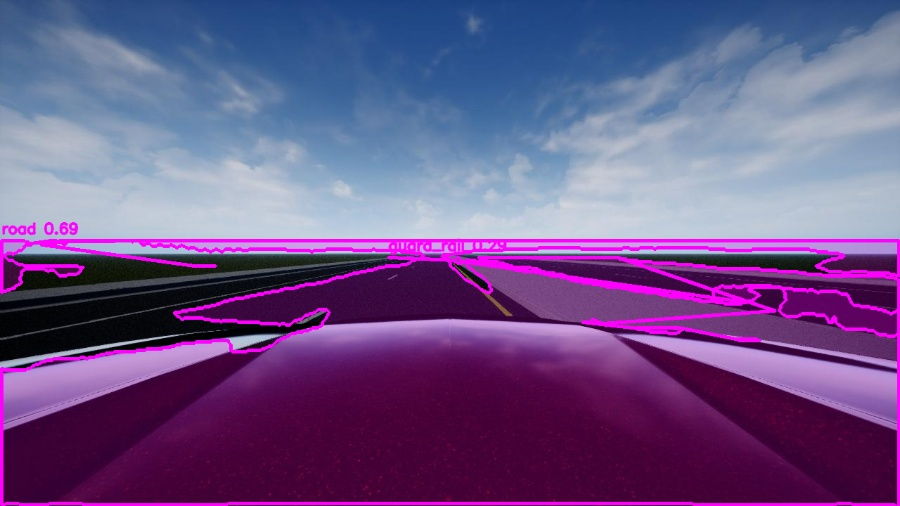


DONE
Objects detected : 2

JSON:
/content/img2/img2.json

Annotated image:
/content/img2/img2_polygon.jpg


In [19]:
from ultralytics import YOLO
import cv2
import numpy as np
import json
import os
import glob
from IPython.display import display, Image

# ============================================================
# 1. PATHS & LOAD MODEL
# ============================================================

model_path = "/content/drive/MyDrive/SIH_Epilgoue/Model/runs_2/merged_idd_rd_model-5/weights/best.pt"
model = YOLO(model_path)

frames_dir = "/content/extracted_frames"
image_paths = sorted(glob.glob(f"{frames_dir}/*.jpg"))

if not image_paths:
    print("No images found in", frames_dir)
else:
    print(f"Found {len(image_paths)} images to process.")

# ============================================================
# 5. DIFFERENT COLORS FOR DIFFERENT OBJECTS
#    OpenCV uses BGR
# ============================================================

colors = [
    (255, 0, 255),    # Pink
    (0, 255, 0),      # Green
    (255, 0, 0),      # Blue
    (0, 165, 255),    # Orange
    (0, 255, 255),    # Yellow
    (255, 255, 0),    # Cyan
    (128, 0, 255),    # Purple
    (0, 128, 255),    # Orange-red
    (255, 255, 255),  # White
    (0, 0, 255)       # Red
]

for image_path in image_paths:
    print(f"\nProcessing {image_path}...")
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    output_dir = f"/content/{image_name}"
    os.makedirs(output_dir, exist_ok=True)
    
    json_path = f"{output_dir}/{image_name}.json"
    image_output_path = f"{output_dir}/{image_name}_polygon.jpg"
    
    # 3. RUN SEGMENTATION
    results = model.predict(source=image_path, conf=0.25, save=False, verbose=False)
    result = results[0]
    
    # 4. LOAD ORIGINAL IMAGE
    img = cv2.imread(image_path)
    if img is None:
        continue
    image_height, image_width = img.shape[:2]
    
    # 6. JSON STRUCTURE
    json_data = {
        "image": image_name,
        "image_width": image_width,
        "image_height": image_height,
        "objects": []
    }
    
    # 7. PROCESS DETECTIONS
    if result.masks is not None and len(result.masks.xy) > 0:
        polygons = result.masks.xy
        classes = result.boxes.cls.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        
        for i, polygon in enumerate(polygons):
            color = colors[i % len(colors)]
            
            class_id = int(classes[i])
            class_name = result.names[class_id]
            confidence = float(confidences[i])
            
            points = np.array(polygon, dtype=np.int32)
            polygon_coordinates = [[round(float(x), 2), round(float(y), 2)] for x, y in polygon]
            
            cv2.polylines(img, [points], isClosed=True, color=color, thickness=3)
            
            overlay = img.copy()
            cv2.fillPoly(overlay, [points], color=color)
            img = cv2.addWeighted(overlay, 0.20, img, 0.80, 0)
            
            x_min = int(np.min(points[:, 0]))
            y_min = int(np.min(points[:, 1]))
            label = f"{class_name} {confidence:.2f}"
            
            cv2.putText(img, label, (x_min, max(y_min - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
            
            object_data = {
                "id": i + 1,
                "class_id": class_id,
                "class": class_name,
                "confidence": round(confidence, 4),
                "polygon": polygon_coordinates
            }
            json_data["objects"].append(object_data)
            
            print(f"\nObject {i + 1}")
            print(f"Class      : {class_name}")
            print(f"Confidence : {confidence:.4f}")
            print(f"Points     : {len(polygon_coordinates)}")
            print(f"Polygon    : {polygon_coordinates}")
    else:
        print("No segmentation objects detected.")
        
    # 8. SAVE JSON
    with open(json_path, "w") as f:
        json.dump(json_data, f, indent=4)
        
    # 9. SAVE FULL-SIZE ANNOTATED IMAGE
    cv2.imwrite(image_output_path, img)
    
    # 10. CREATE SMALLER DISPLAY IMAGE
    display_width = 900
    scale = display_width / img.shape[1]
    display_height = int(img.shape[0] * scale)
    display_img = cv2.resize(img, (display_width, display_height))
    display_path = f"{output_dir}/{image_name}_display.jpg"
    cv2.imwrite(display_path, display_img)
    display(Image(filename=display_path))
    
    # 11. FINAL OUTPUT
    print("\n========================================")
    print("DONE")
    print("========================================")
    print(f"Objects detected : {len(json_data['objects'])}")
    print(f"\nJSON:\n{json_path}")
    print(f"\nAnnotated image:\n{image_output_path}")

print("\nALL FRAMES PROCESSED")
